Day 5–6

Implement:

Logistic regression

Sigmoid

Binary cross entropy

Regularized logistic regression

Extra challenge:

Implement decision boundary plotting

Compare performance with and without feature scaling

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math 


In [2]:
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=500,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    random_state=42
)
w = np.zeros(2)
b=0.0

In [3]:
# Shape Analysis
print(X.shape)
print(y.shape)

(500, 2)
(500,)


In [4]:
print(np.ptp(X))

8.666143987694054


In [5]:
def sigmoid(z):
    g = 1/(1+ np.exp(-z))
    return g

In [6]:
def compute_cost(X,y,w,b, lambda_ = 0):
    m = X.shape[0]

    z = X @ w + b
    y_hat = sigmoid(z)

    loss = np.sum(-y *np.log(y_hat) - ((1-y)*np.log(1-y_hat)))
    cost = loss/m

    reg_cost = (lambda_/(2*m)) * np.sum(w**2)
    return cost + reg_cost


In [7]:
def compute_gradients(X,y,w,b, lambda_ = 0):
    m = X.shape[0]

    z = X@w + b
    y_hat = sigmoid(z)

    error = y_hat - y
    
    dw = (1/m) * (X.T @ error) + (lambda_/m) * w
    db = (1/m) * np.sum(error)

    return dw,db


In [8]:
def gradient_descent(X,y,w,b, alpha, num_iters):
    cost = []
    for i in range(num_iters):
        dw, db = compute_gradients(X,y,w,b)
        w -= alpha * dw
        b -= alpha * db

        #Save cost at each iteration
        
        cost.append(compute_cost(X,y,w,b))
        #Print cost at 
        if i % math.ceil(num_iters/10) == 0:
            print(f"Iteration {i:4}: Cost {cost[-1]:.2e}")
            print(f"dw: {dw}, db: {db}")
            print(f"w: {w}, b: {b}\n")

        
    
    return w,b, cost

In [9]:
w_final, b, cost = gradient_descent(X,y,w,b, alpha=0.01, num_iters=1000)
print(f"w,b found by gradient descent:({w_final, b})")

Iteration    0: Cost 6.90e-01
dw: [-0.53216783  0.02684797], db: -0.002
w: [ 0.00532168 -0.00026848], b: 2e-05

Iteration  100: Cost 5.09e-01
dw: [-0.33636048 -0.00228069], db: 0.0037433109635711974
w: [ 0.42782878 -0.00976258], b: -0.0014427327038829692

Iteration  200: Cost 4.29e-01
dw: [-0.23606006 -0.01102293], db: 0.005244209786760395
w: [ 0.70828495 -0.00216734], b: -0.006118411531295372

Iteration  300: Cost 3.87e-01
dw: [-0.17949624 -0.01329148], db: 0.005565911507635494
w: [0.91339579 0.01028103], b: -0.011570605703600204

Iteration  400: Cost 3.61e-01
dw: [-0.14379208 -0.01347251], db: 0.005566367688417762
w: [1.07363915 0.02375939], b: -0.017150285719724725

Iteration  500: Cost 3.44e-01
dw: [-0.11931257 -0.01293181], db: 0.005465945787276692
w: [1.2043702  0.03699195], b: -0.022670600928780867

Iteration  600: Cost 3.31e-01
dw: [-0.10150204 -0.01215216], db: 0.005328913338408741
w: [1.31425394 0.04953964], b: -0.028069179503175046

Iteration  700: Cost 3.22e-01
dw: [-0.0879

## Plot the Decision Boundary

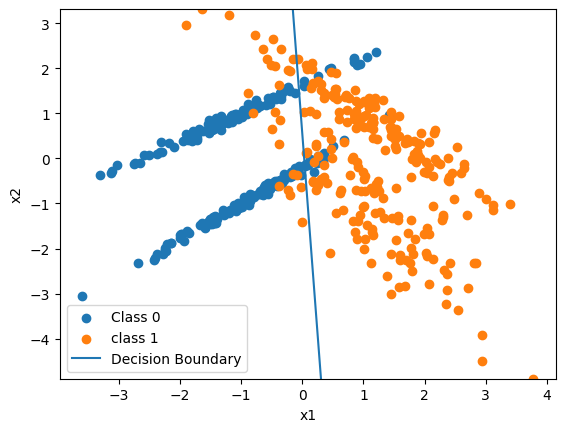

In [ ]:
# class 0
plt.scatter(X[y==0,0], X[y==0,1], label="Class 0")

# class 1
plt.scatter(X[y==1,0], X[y==1,1], label = "class 1")

# Decision Boundary
x1_vals = np.linspace(min(X[:,0]),max(X[:,0]), 100)
x2_vals = -(w[0]*x1_vals+b)/w[1]
plt.plot(x1_vals, x2_vals, label="Decision Boundary")


plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()

plt.ylim(np.min(X[:,1]), np.max(X[:,1]))
plt.show()

In [16]:
print(X.shape)
print(np.min(X[:,1]), np.max(X[:,1]))
print(X[:5])

(500, 2)
-4.887584279073824 3.3114486595457655
[[-1.72495958  0.51149575]
 [-0.52842371 -0.65656693]
 [-1.47146387  0.63515578]
 [-0.57193175  2.20315917]
 [-1.447832    0.74992171]]


In [18]:
X_norm = (X - np.mean(X, axis=0)) / np.std(X, axis=0)

In [ ]:
w_1, b_1, cost_1 = gradient_descent(X_norm,y,w,b, alpha=0.01, num_iters=1000)
print(f"w,b found by gradient descent:({w_1, b_1})")

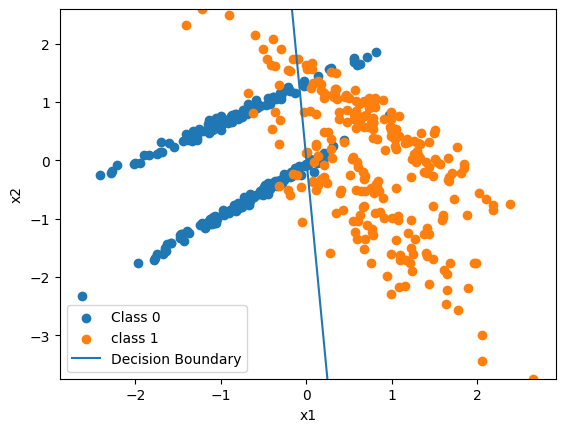

In [21]:
# class 0
plt.scatter(X_norm[y==0,0], X_norm[y==0,1], label="Class 0")

# class 1
plt.scatter(X_norm[y==1,0], X_norm[y==1,1], label = "class 1")

# Decision Boundary
x1_vals = np.linspace(min(X_norm[:,0]),max(X_norm[:,0]), 100)
x2_vals = -(w_1[0]*x1_vals+b_1)/w_1[1]
plt.plot(x1_vals, x2_vals, label="Decision Boundary")


plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()

plt.ylim(np.min(X_norm[:,1]), np.max(X_norm[:,1]))
plt.show()

## Feature Engineering


In [23]:
x1= X[:,0]
x2 = X[:,1]

X_new = np.column_stack([
    x1,
    x2,
    x1*x2,
    x1**2,
    x2**2
])

In [25]:
w = np.zeros(X_new.shape[1])
b=0

w_2, b_2, cost_2 = gradient_descent(X_new,y,w,b, alpha=0.01, num_iters=1000)
print(f"w,b found by gradient descent:({w_2, b_2})")

Iteration    0: Cost 6.89e-01
dw: [-0.53216783  0.02684797  0.34402351 -0.10090006 -0.21540375], db: -0.002
w: [ 0.00532168 -0.00026848 -0.00344024  0.001009    0.00215404], b: 2e-05

Iteration  100: Cost 4.88e-01
dw: [-0.31421173 -0.00665317  0.08270478  0.01350034 -0.02342217], db: 0.02622036650642363
w: [ 0.40474031  0.00124751 -0.16598436  0.00162401  0.0653609 ], b: -0.02271494562192348

Iteration  200: Cost 4.13e-01
dw: [-0.2273834  -0.00516642  0.03998041  0.0068254  -0.01352977], db: 0.022503188468622554
w: [ 0.67035579  0.00720236 -0.22258545 -0.00810158  0.08257885], b: -0.047006437892970106

Iteration  300: Cost 3.71e-01
dw: [-0.17815073 -0.00374646  0.02690249  0.00403213 -0.01042508], db: 0.019780040979690206
w: [ 0.87090993  0.01162442 -0.2548237  -0.0133145   0.09433272], b: -0.06805589429839287

Iteration  400: Cost 3.43e-01
dw: [-0.14618608 -0.00262074  0.02216765  0.00276706 -0.0088025 ], db: 0.017781246070262213
w: [ 1.03189559  0.01478112 -0.27895703 -0.01663538  0.